In [1]:
import torch
import torch.nn as nn
from torchvision import models

MODEL_PATH = r"C:\potenup3\TEAM-PJ-DEEP\document_forms_source\checkpoints\best_model-data2-1000_20260309_Best_Val_Loss_0.1439.pth"
NUM_CLASSES = 14

device = "cuda" if torch.cuda.is_available() else "cpu"


def load_convnext_small(model_path, num_classes):
    # ConvNeXt Small 불러오기
    model = models.convnext_small(weights=None)

    # classifier 수정 (ConvNeXt Small의 마지막 레이어)
    model.classifier[2] = nn.Linear(768, num_classes)

    # 체크포인트 로드
    state_dict = torch.load(model_path, map_location="cpu")
    model.load_state_dict(state_dict)

    # inference 모드
    model.eval()

    return model


model = load_convnext_small(MODEL_PATH, NUM_CLASSES)

print("1번 모델 로드 완료")

print("torch.cuda.is_available() =>", torch.cuda.is_available())

1번 모델 로드 완료
torch.cuda.is_available() => True


In [2]:
from torchvision import datasets, models, transforms


transform_train = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.RandomRotation(2),
        transforms.RandomAffine(degrees=0, translate=(0.02, 0.02)),
        transforms.RandomPerspective(distortion_scale=0.05, p=0.3),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
)

transform_test = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
)

In [3]:
import torch
from torch.utils.data import Dataset
import pandas as pd
from PIL import Image
import os


class MultiLabelDataset(Dataset):

    def __init__(self, csv_file, img_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

        self.labels = self.data.iloc[:, 1:].values

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        img_path = os.path.join(self.img_dir, self.data.iloc[idx, 0])
        image = Image.open(img_path).convert("RGB")

        label = torch.tensor(self.labels[idx], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, label

In [4]:
NUM_CLASSES = 14

train_dataset = MultiLabelDataset(
    csv_file=r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data2\train_labels.csv",
    img_dir=r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data2\train",
    transform=transform_train,
)

val_dataset = MultiLabelDataset(
    csv_file=r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data2\val_labels.csv",
    img_dir=r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data2\val",
    transform=transform_test,
)

test_dataset = MultiLabelDataset(
    csv_file=r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data2\test_labels.csv",
    img_dir=r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data2\test",
    transform=transform_test,
)

In [5]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=8, shuffle=False)

In [6]:
import matplotlib.pyplot as plt


def imshow(img, title):
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    img = img.permute(1, 2, 0)
    img = img * std + mean
    plt.title(title)
    plt.imshow(img)
    plt.show()

In [7]:
model.to("cuda")

ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

In [8]:
import torch
import torchvision
from sklearn.metrics import f1_score, average_precision_score

model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    corrects = 0
    total = 0

    for img, labels in test_dataloader:

        img = img.to(device)
        labels = labels.to(device)

        preds = model(img)
        probs = torch.sigmoid(preds)
        pred = probs > 0.5  # 멀티라벨 예측

        corrects += (pred == labels.bool()).sum().item()
        total += labels.numel()

        # metric 계산용 저장
        all_preds.append(pred.cpu())
        all_labels.append(labels.cpu())
        all_probs.append(probs.cpu())

    acc = corrects / total

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_probs = torch.cat(all_probs).numpy()

    # F1 score
    f1_micro = f1_score(all_labels, all_preds, average="micro")
    f1_macro = f1_score(all_labels, all_preds, average="macro")
    f1_weighted = f1_score(all_labels, all_preds, average="weighted")

    # mAP (mean average precision)
    mAP = average_precision_score(all_labels, all_probs, average="macro")

    print(f"정확도 : {acc:.4f}")
    print(f"F1 micro : {f1_micro:.4f}")
    print(f"F1 macro : {f1_macro:.4f}")
    print(f"F1 weighted : {f1_weighted:.4f}")
    print(f"mAP : {mAP:.4f}")

정확도 : 0.9697
F1 micro : 0.9723
F1 macro : 0.9669
F1 weighted : 0.9716
mAP : 0.9872


In [9]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
THRESHOLD = 0.5
EPS = 1e-12

model = model.to(device)
model.eval()

# accuracy용
total_labels = 0
correct_labels = 0
total_samples = 0
correct_samples = 0

# F1용
tp_micro = 0
fp_micro = 0
fn_micro = 0

num_classes = 14
tp_c = torch.zeros(num_classes, dtype=torch.float64)
fp_c = torch.zeros(num_classes, dtype=torch.float64)
fn_c = torch.zeros(num_classes, dtype=torch.float64)

with torch.no_grad():
    for imgs, labels in test_dataloader:
        imgs = imgs.to(device)
        labels = labels.to(device).int()

        logits = model(imgs)
        probs = torch.sigmoid(logits)
        preds = (probs > THRESHOLD).int()

        # acc
        correct_labels += (preds == labels).sum().item()
        total_labels += labels.numel()

        correct_samples += (preds == labels).all(dim=1).sum().item()
        total_samples += labels.size(0)

        # micro F1
        tp_micro += ((preds == 1) & (labels == 1)).sum().item()
        fp_micro += ((preds == 1) & (labels == 0)).sum().item()
        fn_micro += ((preds == 0) & (labels == 1)).sum().item()

        # macro F1
        tp_c += ((preds == 1) & (labels == 1)).sum(dim=0).cpu().double()
        fp_c += ((preds == 1) & (labels == 0)).sum(dim=0).cpu().double()
        fn_c += ((preds == 0) & (labels == 1)).sum(dim=0).cpu().double()

# accuracy
label_acc = correct_labels / total_labels
subset_acc = correct_samples / total_samples

# micro F1
precision_micro = tp_micro / (tp_micro + fp_micro + EPS)
recall_micro = tp_micro / (tp_micro + fn_micro + EPS)
f1_micro = 2 * precision_micro * recall_micro / (precision_micro + recall_micro + EPS)

# macro F1
precision_per_class = tp_c / (tp_c + fp_c + EPS)
recall_per_class = tp_c / (tp_c + fn_c + EPS)
f1_per_class = (
    2
    * precision_per_class
    * recall_per_class
    / (precision_per_class + recall_per_class + EPS)
)
f1_macro = f1_per_class.mean().item()

print(
    f"label_acc:  {label_acc*100:.2f}% (모든 테스트 이미지의 모든 라벨을 다 펼처서 정확도 확인)"
)
print(f"subset_acc: {subset_acc*100:.2f}% (14개 전부 맞춘 비율)")
print(
    f"f1_micro:   {f1_micro*100:.2f}% (작성됨(1)에 대해 잘못 예측한 경우(FP)와 놓친 경우(FN)를 함께 고려한 전체 성능 지표)"
)
print(
    f"f1_macro:   {f1_macro*100:.2f}% (라벨별 F1을 구해 평균 14개 항목을 비슷하게 잘 맞추고 있다는 신호)"
)

label_acc:  96.97% (모든 테스트 이미지의 모든 라벨을 다 펼처서 정확도 확인)
subset_acc: 67.55% (14개 전부 맞춘 비율)
f1_micro:   97.23% (작성됨(1)에 대해 잘못 예측한 경우(FP)와 놓친 경우(FN)를 함께 고려한 전체 성능 지표)
f1_macro:   96.69% (라벨별 F1을 구해 평균 14개 항목을 비슷하게 잘 맞추고 있다는 신호)


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

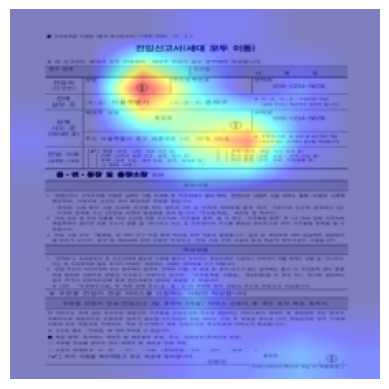

In [10]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

model.eval()
model.to("cuda")

img = Image.open(
    r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data2\test\학습-전입신고서15.jpg"
).convert("RGB")
input_tensor = transform_test(img).unsqueeze(0).to("cuda")

# 마지막 stage grad 활성화
for param in model.features[-1].parameters():
    param.requires_grad = True

pred = model(input_tensor)

target_class = 2

target_layers = [model.features[-1][-1]]

cam = GradCAM(model=model, target_layers=target_layers)

grad_cam = cam(
    input_tensor=input_tensor, targets=[ClassifierOutputTarget(target_class)]
)[0]

rgb_img = np.array(img.resize((224, 224))).astype(np.float32) / 255.0
visualization = show_cam_on_image(rgb_img, grad_cam, use_rgb=True)

plt.imshow(visualization)
plt.axis("off")

In [11]:
import torch
import torch.nn as nn
from torchvision import models

MODEL_PATH = r"C:\potenup3\TEAM-PJ-DEEP\document_forms_source\checkpoints\best_model-data2-4000-unfreezed_20260309-val_loss_0.0087.pth"
NUM_CLASSES = 14

device = "cuda" if torch.cuda.is_available() else "cpu"


def load_convnext_small(model_path, num_classes):
    # ConvNeXt Small 불러오기
    model = models.convnext_small(weights=None)

    # classifier 수정 (ConvNeXt Small의 마지막 레이어)
    model.classifier[2] = nn.Linear(768, num_classes)

    # 체크포인트 로드
    state_dict = torch.load(model_path, map_location="cpu")
    model.load_state_dict(state_dict)

    # inference 모드
    model.eval()

    return model


model = load_convnext_small(MODEL_PATH, NUM_CLASSES)

print("2회차 모델 로드 완료")

print("torch.cuda.is_available() =>", torch.cuda.is_available())

2회차 모델 로드 완료
torch.cuda.is_available() => True


In [12]:
from torchvision import datasets, models, transforms

transform_train = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.RandomRotation(2),
        transforms.RandomAffine(degrees=0, translate=(0.02, 0.02)),
        transforms.RandomPerspective(distortion_scale=0.05, p=0.3),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.9367, 0.9364, 0.9358], [0.0957, 0.0964, 0.0963]),
    ]
)
transform_test = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.9367, 0.9364, 0.9358], [0.0957, 0.0964, 0.0963]),
    ]
)

In [13]:
import torch
from torch.utils.data import Dataset
import pandas as pd
from PIL import Image
import os


class MultiLabelDataset(Dataset):

    def __init__(self, csv_file, img_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

        self.labels = self.data.iloc[:, 1:].values

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        img_path = os.path.join(self.img_dir, self.data.iloc[idx, 0])
        image = Image.open(img_path).convert("RGB")

        label = torch.tensor(self.labels[idx], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, label

In [14]:
NUM_CLASSES = 14

train_dataset = MultiLabelDataset(
    csv_file=r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data2-4000\train_labels_4000.csv",
    img_dir=r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data2-4000\train_4000",
    transform=transform_train,
)

val_dataset = MultiLabelDataset(
    csv_file=r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data2-4000\val_labels_4000.csv",
    img_dir=r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data2-4000\val_4000",
    transform=transform_test,
)

test_dataset = MultiLabelDataset(
    csv_file=r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data2-4000\test_labels_4000.csv",
    img_dir=r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data2-4000\test_4000",
    transform=transform_test,
)

In [15]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=8, shuffle=False)

In [16]:
model.to("cuda")

ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

In [17]:
image = Image.open(
    r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data2\test\학습-전입신고서15.jpg"
).convert("RGB")


input_tensor_image = transform_test(image).to(device)

model.eval()

with torch.no_grad():

    output = model(input_tensor_image.unsqueeze(0).cuda())
    probs = torch.sigmoid(output)

    print(probs)

    preds = (probs > 0.5).int()

print(preds)

tensor([[6.0740e-05, 9.9976e-01, 9.1735e-02, 9.9604e-01, 9.9585e-01, 4.3602e-01,
         2.8366e-01, 9.8448e-01, 9.9428e-01, 9.9840e-01, 3.9512e-01, 6.8997e-01,
         5.7315e-01, 4.4301e-01]], device='cuda:0')
tensor([[0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0]], device='cuda:0',
       dtype=torch.int32)


In [18]:
import matplotlib.pyplot as plt
import torch


def imshow(img, title):
    mean = torch.tensor([0.9367, 0.9364, 0.9358])
    std = torch.tensor([0.0957, 0.0964, 0.0963])

    img = img.permute(1, 2, 0)
    img = img * std + mean
    img = img.clamp(0, 1)

    plt.title(title)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [1]:
import torch
import torchvision
from sklearn.metrics import f1_score, average_precision_score

model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    corrects = 0
    total = 0

    for img, labels in test_dataloader:

        img = img.to(device)
        labels = labels.to(device)

        preds = model(img)
        probs = torch.sigmoid(preds)
        pred = probs > 0.5  # 멀티라벨 예측

        corrects += (pred == labels.bool()).sum().item()
        total += labels.numel()

        # metric 계산용 저장
        all_preds.append(pred.cpu())
        all_labels.append(labels.cpu())
        all_probs.append(probs.cpu())

    acc = corrects / total

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_probs = torch.cat(all_probs).numpy()

    # F1 score
    f1_micro = f1_score(all_labels, all_preds, average="micro")
    f1_macro = f1_score(all_labels, all_preds, average="macro")
    f1_weighted = f1_score(all_labels, all_preds, average="weighted")

    # mAP (mean average precision)
    mAP = average_precision_score(all_labels, all_probs, average="macro")

    print(f"정확도 : {acc:.4f}")
    print(f"F1 micro : {f1_micro:.4f}")
    print(f"F1 macro : {f1_macro:.4f}")
    print(f"F1 weighted : {f1_weighted:.4f}")
    print(f"mAP : {mAP:.4f}")

NameError: name 'model' is not defined

In [20]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
THRESHOLD = 0.5
EPS = 1e-12

model = model.to(device)
model.eval()

# accuracy용
total_labels = 0
correct_labels = 0
total_samples = 0
correct_samples = 0

# F1용
tp_micro = 0
fp_micro = 0
fn_micro = 0

num_classes = 14
tp_c = torch.zeros(num_classes, dtype=torch.float64)
fp_c = torch.zeros(num_classes, dtype=torch.float64)
fn_c = torch.zeros(num_classes, dtype=torch.float64)

with torch.no_grad():
    for imgs, labels in test_dataloader:
        imgs = imgs.to(device)
        labels = labels.to(device).int()

        logits = model(imgs)
        probs = torch.sigmoid(logits)
        preds = (probs > THRESHOLD).int()

        # acc
        correct_labels += (preds == labels).sum().item()
        total_labels += labels.numel()

        correct_samples += (preds == labels).all(dim=1).sum().item()
        total_samples += labels.size(0)

        # micro F1
        tp_micro += ((preds == 1) & (labels == 1)).sum().item()
        fp_micro += ((preds == 1) & (labels == 0)).sum().item()
        fn_micro += ((preds == 0) & (labels == 1)).sum().item()

        # macro F1
        tp_c += ((preds == 1) & (labels == 1)).sum(dim=0).cpu().double()
        fp_c += ((preds == 1) & (labels == 0)).sum(dim=0).cpu().double()
        fn_c += ((preds == 0) & (labels == 1)).sum(dim=0).cpu().double()

# accuracy
label_acc = correct_labels / total_labels
subset_acc = correct_samples / total_samples

# micro F1
precision_micro = tp_micro / (tp_micro + fp_micro + EPS)
recall_micro = tp_micro / (tp_micro + fn_micro + EPS)
f1_micro = 2 * precision_micro * recall_micro / (precision_micro + recall_micro + EPS)

# macro F1
precision_per_class = tp_c / (tp_c + fp_c + EPS)
recall_per_class = tp_c / (tp_c + fn_c + EPS)
f1_per_class = (
    2
    * precision_per_class
    * recall_per_class
    / (precision_per_class + recall_per_class + EPS)
)
f1_macro = f1_per_class.mean().item()

print(
    f"label_acc:  {label_acc*100:.2f}% (모든 테스트 이미지의 모든 라벨을 다 펼처서 정확도 확인)"
)
print(f"subset_acc: {subset_acc*100:.2f}% (14개 전부 맞춘 비율)")
print(
    f"f1_micro:   {f1_micro*100:.2f}% (작성됨(1)에 대해 잘못 예측한 경우(FP)와 놓친 경우(FN)를 함께 고려한 전체 성능 지표)"
)
print(
    f"f1_macro:   {f1_macro*100:.2f}% (라벨별 F1을 구해 평균 14개 항목을 비슷하게 잘 맞추고 있다는 신호)"
)

label_acc:  92.92% (모든 테스트 이미지의 모든 라벨을 다 펼처서 정확도 확인)
subset_acc: 27.29% (14개 전부 맞춘 비율)
f1_micro:   94.93% (작성됨(1)에 대해 잘못 예측한 경우(FP)와 놓친 경우(FN)를 함께 고려한 전체 성능 지표)
f1_macro:   95.45% (라벨별 F1을 구해 평균 14개 항목을 비슷하게 잘 맞추고 있다는 신호)


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

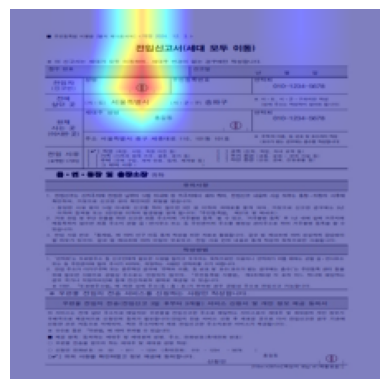

In [21]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

model.eval()
model.to("cuda")

target_class = 1
img = Image.open(
    r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data2\test\학습-전입신고서15.jpg"
).convert("RGB")
input_tensor = transform_test(img).unsqueeze(0).to("cuda")

# 마지막 stage grad 활성화
for param in model.features[-1].parameters():
    param.requires_grad = True

pred = model(input_tensor)


target_layers = [model.features[-1][-1]]

cam = GradCAM(model=model, target_layers=target_layers)

grad_cam = cam(
    input_tensor=input_tensor, targets=[ClassifierOutputTarget(target_class)]
)[0]

rgb_img = np.array(img.resize((224, 224))).astype(np.float32) / 255.0
visualization = show_cam_on_image(rgb_img, grad_cam, use_rgb=True)

plt.imshow(visualization)
plt.axis("off")

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

MODEL_PATH = r"C:\potenup3\TEAM-PJ-DEEP\document_forms_source\checkpoints\optuna_final_trial_4_best_0.00824.pth"
NUM_CLASSES = 14

device = "cuda" if torch.cuda.is_available() else "cpu"


def load_convnext_small(model_path, num_classes):
    # ConvNeXt Small 불러오기
    model = models.convnext_small(weights=None)

    # classifier 수정 (ConvNeXt Small의 마지막 레이어)
    model.classifier[2] = nn.Linear(768, num_classes)

    # 체크포인트 로드
    state_dict = torch.load(model_path)
    model.load_state_dict(state_dict)

    # inference 모드
    model.eval()

    return model


model = load_convnext_small(MODEL_PATH, NUM_CLASSES)

print("optuna돌린 모델 로드 완료")

print("torch.cuda.is_available() =>", torch.cuda.is_available())

optuna돌린 모델 로드 완료
torch.cuda.is_available() => True


In [11]:
model.to("cuda")

ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

In [12]:
import torch
import torchvision
from sklearn.metrics import f1_score, average_precision_score

model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    corrects = 0
    total = 0

    for img, labels in test_dataloader:

        img = img.to(device)
        labels = labels.to(device)

        preds = model(img)
        probs = torch.sigmoid(preds)
        pred = probs > 0.5  # 멀티라벨 예측

        corrects += (pred == labels.bool()).sum().item()
        total += labels.numel()

        # metric 계산용 저장
        all_preds.append(pred.cpu())
        all_labels.append(labels.cpu())
        all_probs.append(probs.cpu())

    acc = corrects / total

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_probs = torch.cat(all_probs).numpy()

    # F1 score
    f1_micro = f1_score(all_labels, all_preds, average="micro")
    f1_macro = f1_score(all_labels, all_preds, average="macro")
    f1_weighted = f1_score(all_labels, all_preds, average="weighted")

    # mAP (mean average precision)
    mAP = average_precision_score(all_labels, all_probs, average="macro")

    print(f"정확도 : {acc:.4f}")
    print(f"F1 micro : {f1_micro:.4f}")
    print(f"F1 macro : {f1_macro:.4f}")
    print(f"F1 weighted : {f1_weighted:.4f}")
    print(f"mAP : {mAP:.4f}")

정확도 : 0.9763
F1 micro : 0.9782
F1 macro : 0.9847
F1 weighted : 0.9778
mAP : 0.9998


In [23]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
THRESHOLD = 0.5
EPS = 1e-12

model = model.to(device)
model.eval()

# accuracy용
total_labels = 0
correct_labels = 0
total_samples = 0
correct_samples = 0

# F1용
tp_micro = 0
fp_micro = 0
fn_micro = 0

num_classes = 14
tp_c = torch.zeros(num_classes, dtype=torch.float64)
fp_c = torch.zeros(num_classes, dtype=torch.float64)
fn_c = torch.zeros(num_classes, dtype=torch.float64)

with torch.no_grad():
    for imgs, labels in test_dataloader:
        imgs = imgs.to(device)
        labels = labels.to(device).int()

        logits = model(imgs)
        probs = torch.sigmoid(logits)
        preds = (probs > THRESHOLD).int()

        # acc
        correct_labels += (preds == labels).sum().item()
        total_labels += labels.numel()

        correct_samples += (preds == labels).all(dim=1).sum().item()
        total_samples += labels.size(0)

        # micro F1
        tp_micro += ((preds == 1) & (labels == 1)).sum().item()
        fp_micro += ((preds == 1) & (labels == 0)).sum().item()
        fn_micro += ((preds == 0) & (labels == 1)).sum().item()

        # macro F1
        tp_c += ((preds == 1) & (labels == 1)).sum(dim=0).cpu().double()
        fp_c += ((preds == 1) & (labels == 0)).sum(dim=0).cpu().double()
        fn_c += ((preds == 0) & (labels == 1)).sum(dim=0).cpu().double()

# accuracy
label_acc = correct_labels / total_labels
subset_acc = correct_samples / total_samples

# micro F1
precision_micro = tp_micro / (tp_micro + fp_micro + EPS)
recall_micro = tp_micro / (tp_micro + fn_micro + EPS)
f1_micro = 2 * precision_micro * recall_micro / (precision_micro + recall_micro + EPS)

# macro F1
precision_per_class = tp_c / (tp_c + fp_c + EPS)
recall_per_class = tp_c / (tp_c + fn_c + EPS)
f1_per_class = (
    2
    * precision_per_class
    * recall_per_class
    / (precision_per_class + recall_per_class + EPS)
)
f1_macro = f1_per_class.mean().item()

print(
    f"label_acc:  {label_acc*100:.2f}% (모든 테스트 이미지의 모든 라벨을 다 펼처서 정확도 확인)"
)
print(f"subset_acc: {subset_acc*100:.2f}% (14개 전부 맞춘 비율)")
print(
    f"f1_micro:   {f1_micro*100:.2f}% (작성됨(1)에 대해 잘못 예측한 경우(FP)와 놓친 경우(FN)를 함께 고려한 전체 성능 지표)"
)
print(
    f"f1_macro:   {f1_macro*100:.2f}% (라벨별 F1을 구해 평균 14개 항목을 비슷하게 잘 맞추고 있다는 신호)"
)

label_acc:  90.88% (모든 테스트 이미지의 모든 라벨을 다 펼처서 정확도 확인)
subset_acc: 28.62% (14개 전부 맞춘 비율)
f1_micro:   93.38% (작성됨(1)에 대해 잘못 예측한 경우(FP)와 놓친 경우(FN)를 함께 고려한 전체 성능 지표)
f1_macro:   93.98% (라벨별 F1을 구해 평균 14개 항목을 비슷하게 잘 맞추고 있다는 신호)


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

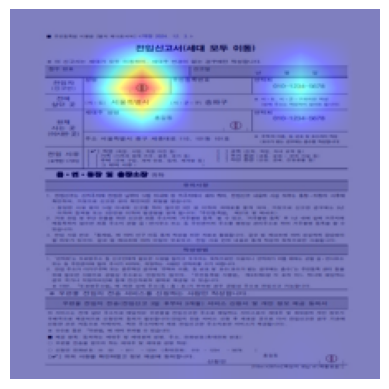

In [13]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

model.eval()
model.to("cuda")

target_class = 1
img = Image.open(
    r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data2\test\학습-전입신고서15.jpg"
).convert("RGB")
input_tensor = transform_test(img).unsqueeze(0).to("cuda")

# 마지막 stage grad 활성화
for param in model.features[-1].parameters():
    param.requires_grad = True

pred = model(input_tensor)


target_layers = [model.features[-1][-1]]

cam = GradCAM(model=model, target_layers=target_layers)

grad_cam = cam(
    input_tensor=input_tensor, targets=[ClassifierOutputTarget(target_class)]
)[0]

rgb_img = np.array(img.resize((224, 224))).astype(np.float32) / 255.0
visualization = show_cam_on_image(rgb_img, grad_cam, use_rgb=True)

plt.imshow(visualization)
plt.axis("off")